<a href="https://colab.research.google.com/github/skyish21/AIML-Python/blob/main/DL/DL_5%20Dog%20vs%20Cat%20using%20Transfer%20Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Transfer Learning**:
 DL technique where we use a pre-trained model. This pre-trianed model is trained for one task and can be re-trained for a similar task with a smaller dataset.

 VGG-16

 ResNet50

 Inceptionv3

 MobileNet V2

 Yolo V5

In [ ]:
#Extracting the Dataset using Kaggle Library API
!pip install kaggle

In [ ]:
# Configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

### Importing Dataset

In [ ]:
# Kaggle API
!kaggle competitions download -c dogs-vs-cats

 95% 772M/812M [00:12<00:00, 88.8MB/s]
100% 812M/812M [00:12<00:00, 66.4MB/s]


In [ ]:
!ls

'cat img 1.jpeg'   dogs-vs-cats.zip   sample_data
'dog img 1.jpg'    kaggle.json


In [ ]:
# Extracting the compressed file
from zipfile import ZipFile

# Open the zip file
data = ZipFile('/content/dogs-vs-cats.zip')

# Use the opened zip file object to extract all contents
with data as zip:
  zip.extractall()
  print('Done')

Done


In [ ]:
# Extracting the compressed file
from zipfile import ZipFile

# Open the zip file
data = ZipFile('/content/train.zip')

# Use the opened zip file object to extract all contents
with data as zip:
  zip.extractall()
  print('Done')

Done


In [ ]:
import os

# Counting number of files from train folder
path, dirs, files = next(os.walk("/content/train"))
file_count = len(files)
print(file_count)

25000


In [ ]:
# No. of train images : 25000

In [ ]:
# File names in train dataset
file_names = os.listdir("/content/train")
print(file_names)

['cat.4051.jpg', 'cat.2581.jpg', 'dog.1256.jpg', 'cat.1347.jpg', 'dog.6917.jpg', 'dog.7145.jpg', 'cat.7393.jpg', 'dog.9406.jpg', 'dog.8504.jpg', 'dog.4575.jpg', 'cat.3467.jpg', 'dog.3300.jpg', 'dog.9158.jpg', 'dog.8339.jpg', 'dog.6408.jpg', 'dog.11751.jpg', 'dog.7979.jpg', 'dog.8553.jpg', 'dog.2135.jpg', 'dog.6279.jpg', 'cat.310.jpg', 'cat.3554.jpg', 'cat.11056.jpg', 'dog.1488.jpg', 'cat.4469.jpg', 'dog.11361.jpg', 'dog.2252.jpg', 'cat.8866.jpg', 'dog.10387.jpg', 'dog.9394.jpg', 'cat.2487.jpg', 'dog.2441.jpg', 'dog.9400.jpg', 'dog.1631.jpg', 'cat.625.jpg', 'cat.9905.jpg', 'dog.12430.jpg', 'dog.10265.jpg', 'dog.8249.jpg', 'cat.9860.jpg', 'cat.5882.jpg', 'dog.1111.jpg', 'cat.3537.jpg', 'cat.619.jpg', 'cat.6493.jpg', 'cat.1249.jpg', 'dog.9954.jpg', 'dog.10250.jpg', 'dog.10857.jpg', 'cat.9013.jpg', 'cat.10883.jpg', 'dog.4451.jpg', 'dog.6147.jpg', 'dog.8626.jpg', 'dog.9516.jpg', 'dog.2363.jpg', 'cat.2365.jpg', 'cat.1641.jpg', 'cat.9238.jpg', 'dog.5609.jpg', 'dog.10193.jpg', 'dog.2868.jpg', 

In [ ]:
# Count dog and cat images based on filename prefix
dog_count = len([f for f in file_names if f.startswith('dog')])
cat_count = len([f for f in file_names if f.startswith('cat')])

print(f"Dog images: {dog_count}")
print(f"Cat images: {cat_count}")

Dog images: 12500
Cat images: 12500


In [ ]:
# Importing the dependencies
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from google.colab.patches import cv2_imshow

In [ ]:
# Displaying the Training set

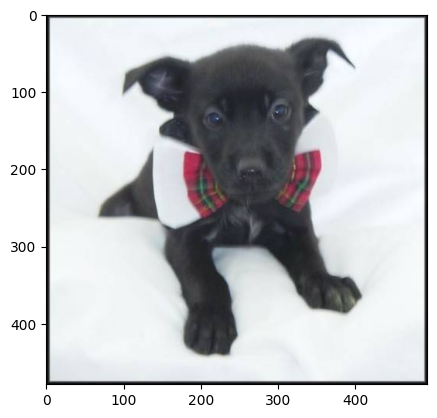

In [ ]:
# Few Dog Images

for i in range(11095, 11096):
  img = mpimg.imread("/content/train/dog." + str(i) + ".jpg")
  imgplot = plt.imshow(img)
  plt.show()

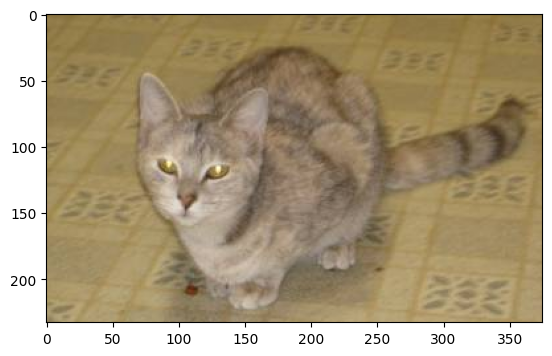

In [ ]:
# Few Cat Images

for i in range(4051, 4052):
  img = mpimg.imread("/content/train/cat." + str(i) + ".jpg")
  imgplot = plt.imshow(img)
  plt.show()

In [ ]:
# All the images are of different size. Model needs to be trained on images of similar size.
# Model can be trained on Gray scale images if RGB features aren't necesarry.
# Training Model on Gray scale images requires lesser time.

### Pre-Processing the Images

In [ ]:
# Creating a directory for resized images
os.mkdir('/content/resized_images')

In [ ]:
for i in range(2000):

  filename = os.listdir('/content/train')[i]
  img_path = '/content/train/' + filename

  # Using PIL library
  img = Image.open(img_path)
  img = img.resize((224, 224))
  img = img.convert('RGB')

  new_img_path = '/content/resized_images/' + filename
  img.save(new_img_path)

In [ ]:
# Get File names
file_names_resized = os.listdir('/content/resized_images')
print(file_names_resized)

['cat.4051.jpg', 'cat.2581.jpg', 'dog.1256.jpg', 'cat.1347.jpg', 'dog.6917.jpg', 'dog.7145.jpg', 'cat.7393.jpg', 'dog.9406.jpg', 'dog.8504.jpg', 'dog.4575.jpg', 'cat.3467.jpg', 'dog.3300.jpg', 'dog.9158.jpg', 'dog.8339.jpg', 'dog.6408.jpg', 'dog.11751.jpg', 'dog.7979.jpg', 'dog.8553.jpg', 'dog.2135.jpg', 'dog.6279.jpg', 'cat.310.jpg', 'cat.3554.jpg', 'cat.11056.jpg', 'dog.1488.jpg', 'cat.4469.jpg', 'dog.11361.jpg', 'dog.2252.jpg', 'cat.8866.jpg', 'dog.10387.jpg', 'dog.9394.jpg', 'cat.2487.jpg', 'dog.2441.jpg', 'dog.9400.jpg', 'dog.1631.jpg', 'cat.625.jpg', 'cat.9905.jpg', 'dog.12430.jpg', 'dog.10265.jpg', 'dog.8249.jpg', 'cat.9860.jpg', 'cat.5882.jpg', 'dog.1111.jpg', 'cat.3537.jpg', 'cat.619.jpg', 'cat.6493.jpg', 'cat.1249.jpg', 'dog.9954.jpg', 'dog.10250.jpg', 'dog.10857.jpg', 'cat.9013.jpg', 'cat.10883.jpg', 'dog.4451.jpg', 'dog.6147.jpg', 'dog.8626.jpg', 'dog.9516.jpg', 'dog.2363.jpg', 'cat.2365.jpg', 'cat.1641.jpg', 'cat.9238.jpg', 'dog.5609.jpg', 'dog.10193.jpg', 'dog.2868.jpg', 

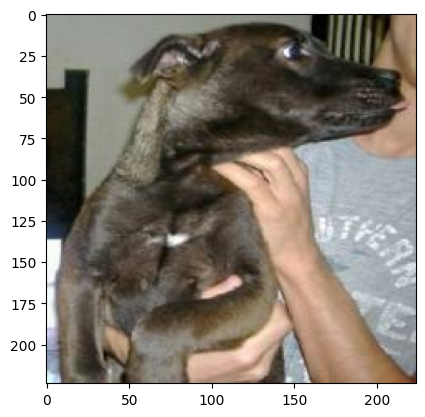

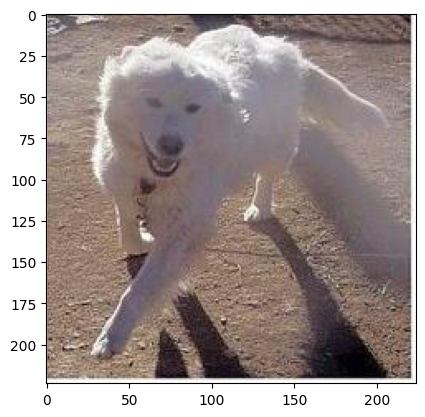

In [ ]:
# Few Dog Images

count = 0

for i in file_names_resized:

  # name slices the first three characters of string/file name (For eg. "dog.1234.jpg"[0:3]" -> dog")
  name = i[0:3]

  if name == 'dog':
    img = mpimg.imread("/content/resized_images/" + str(i))
    imgplot = plt.imshow(img)
    plt.show()
    count += 1
    if count == 2:
        break

In [ ]:
# Alternative method 1

"""
dog_images = [f for f in file_names_resized if f.startswith('dog')][:5]

for i in dog_images:
    img = mpimg.imread("/content/resized_images/" + i)
    plt.imshow(img)
    plt.show()
"""

# Alternative method 2

"""
count = 0

for i in file_names_resized:
    if i.startswith('dog'):
        img = mpimg.imread("/content/resized_images/" + i)
        plt.imshow(img)
        plt.show()
        count += 1
        if count == 5:
            break
"""

'\ncount = 0\n\nfor i in file_names_resized:\n    if i.startswith(\'dog\'):\n        img = mpimg.imread("/content/resized_images/" + i)\n        plt.imshow(img)\n        plt.show()\n        count += 1\n        if count == 5:\n            break\n'

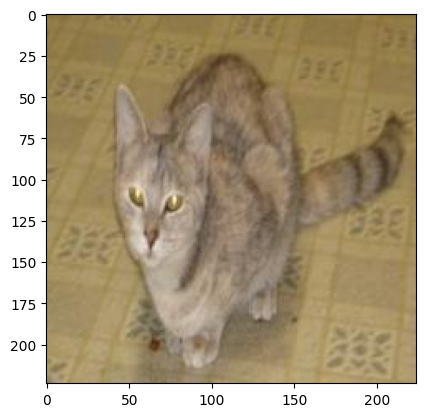

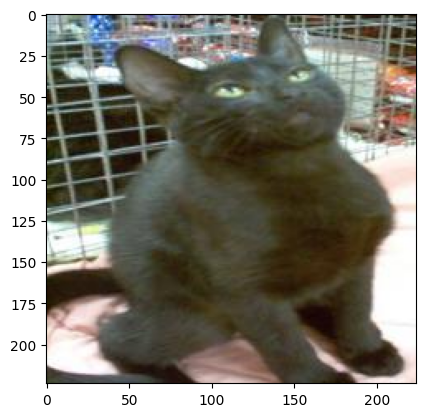

In [ ]:
# Few Resized Cat Images

count = 0;

for i in file_names_resized:

  name = i[0:3]

  if name == 'cat':
    img = mpimg.imread("/content/resized_images/" + str(i))
    imgplot = plt.imshow(img)
    plt.show()
    count += 1
    if count == 2:
        break

In [ ]:
# Create labels for images

labels = []

for i in file_names_resized:

  name = i[0:3]

  if name == "dog":
    labels.append(1)
  else:
    labels.append(0)

In [ ]:
# Print first 10 labels
print(labels[:10])

[0, 0, 1, 0, 1, 1, 0, 1, 1, 1]


In [ ]:
# Count no. of images for dogs and cats
dog_count = len([f for f in file_names_resized if f.startswith('dog')])
cat_count = len([f for f in file_names_resized if f.startswith('cat')])

print(f"Dog images: {dog_count}")
print(f"Cat images: {cat_count}")

Dog images: 1020
Cat images: 980


In [ ]:
np.unique(labels, return_counts = True)

(array([0, 1]), array([ 980, 1020]))

In [ ]:
print(len(file_names_resized))

2000


In [ ]:
# Convert the images to numpy array

import cv2
import glob

files = []

image_dir = "/content/resized_images/"
image_extension = ['png', 'jpg']

[files.extend(glob.glob(image_dir + "*." + e)) for e in image_extension]

dog_cat_images = np.asarray([cv2.imread(file) for file in files])

In [ ]:
#print(dog_cat_images) #prints image converted to array

In [ ]:
type(dog_cat_images)

numpy.ndarray

In [ ]:
dog_cat_images.shape

(2000, 224, 224, 3)

### Features and Labels


In [ ]:
x = dog_cat_images
y = np.asarray(labels)

### Train Test Split

In [ ]:
xtrain,xtest,ytrain,ytest = train_test_split  (x,y,test_size=0.2,random_state=101)

In [ ]:
print(xtrain.shape, xtest.shape)

(1600, 224, 224, 3) (400, 224, 224, 3)


In [ ]:
print(ytrain.shape, ytest.shape)

(1600,) (400,)


# Scaling the data

In [ ]:
# Bring all the values in 0-1 range
xtrain = xtrain/255
xtest = xtest/255

In [ ]:
#print(xtrain) # print training array

### Build NN Model

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras.applications import MobileNet

In [ ]:
pretrained_model_layer = MobileNet(weights='imagenet', include_top=False, input_shape=(224,224,3))

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Alternative way

# Get MobileNet Model
#MN_model = MN_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

In [ ]:
pretrained_model_layer.trainable = False

In [ ]:
num_of_classes = 2

In [ ]:
model = tf.keras.Sequential([

    pretrained_model_layer,
    tf.keras.layers.GlobalAveragePooling2D(),       # Turns (7, 7, 1024) into (1024,)
    tf.keras.layers.Dense(2, activation='softmax')  # Binary classification
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_1.00_224 (Functional) │ (None, 7, 7, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,230,914 (12.32 MB)

 Trainable params: 2,050 (8.01 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model.fit(xtrain, ytrain, epochs=5)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.7520 - loss: 0.5146
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.9688 - loss: 0.0959
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9720 - loss: 0.0796
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.9813 - loss: 0.0657
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.9924 - loss: 0.0457


In [ ]:
model.evaluate(xtest, ytest)

13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.9679 - loss: 0.0734


[0.06683681160211563, 0.9725000262260437]

### Build Predictive System

In [ ]:
def model_predict():

  img_path = input("Enter the image path: ")

  # Display the image
  img = cv2.imread(img_path)


  # Resize the image
  img_resize = cv2.resize(img, (224, 224))
  cv2_imshow(img_resize)

  # Convert the image to array
  img_array = tf.keras.utils.img_to_array(img_resize)

  # Scale the image
  img_scale = img_array / 255.0

  # Reshape the image (lets model know the no. of images inputed)
  img_reshape = np.reshape(img_scale, [1, 224, 224, 3])

  # Predict the image
  prediction = model.predict(img_reshape)

  # Get highest probabilty
  pred_label = np.argmax(prediction)

  if pred_label == 0:
    print("The image is a cat")
  else:
    print("The image is a dog")

Enter the image path: /content/cat img 1.jpeg


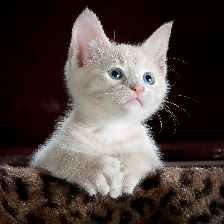

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
The image is a cat


In [ ]:
model_predict()

Enter the image path: /content/dog img 1.jpg


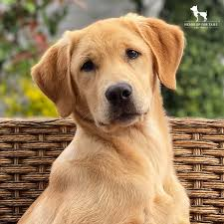

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
The image is a dog


In [ ]:
model_predict()